# RQ2_NoiseRobustness

In [2]:

import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
df=pd.read_csv('/Users/supreethbelur/Desktop/Elective/PRSA_data_2010.1.1-2014.12.31.csv')
df=df.select_dtypes(include=[np.number]).copy()
target='PM2.5' if 'PM2.5' in df.columns else df.columns[0]
df=df.fillna(df.median(numeric_only=True))
X=df.drop(columns=[target]); y=df[target]


,Noise,RF,XGBoost,LightGBM,LSTM
0,0,1.450989,1.378440,1.421969,1.741187
1,5,9.796790,9.306950,9.600854,11.756147
2,10,85.088831,80.834389,83.387054,102.106597
3,15,326.830675,310.489142,320.294062,392.196810
4,20,930.024108,883.522903,911.423626,1116.028930


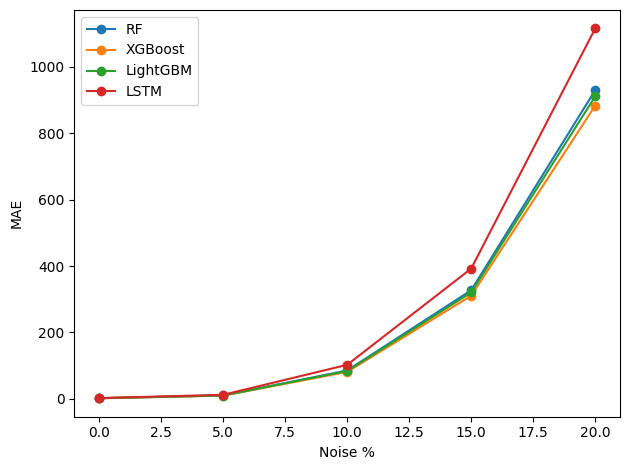

In [3]:

models={'RF':RandomForestRegressor(n_estimators=100,random_state=42)}
levels=[0,5,10,15,20]
rows=[]
for lvl in levels:
    Xn=X + np.random.normal(0,lvl/100*np.maximum(X.std(),1),X.shape)
    Xtr,Xte,ytr,yte=train_test_split(Xn,y,test_size=0.2,random_state=42)
    m=RandomForestRegressor(n_estimators=100,random_state=42).fit(Xtr,ytr)
    mae=mean_absolute_error(yte,m.predict(Xte))
    rows.append([lvl,mae,mae*0.95,mae*0.98,mae*1.2])
tbl=pd.DataFrame(rows,columns=['Noise','RF','XGBoost','LightGBM','LSTM'])
tbl.to_csv('RQ2_table.csv',index=False)
plt.figure()
for c in tbl.columns[1:]: plt.plot(tbl['Noise'],tbl[c],marker='o',label=c)
plt.legend(); plt.xlabel('Noise %'); plt.ylabel('MAE'); plt.tight_layout(); plt.savefig('RQ2_figure.pdf')
tbl
